# SquareOscillator Strategies

This notebook demonstrates the different square wave generation algorithms available
in AudioPlayground. Each strategy produces a different character of square wave,
from ideal (aliased) to bandlimited (antialiased) to analog-style variations.

Available strategies:
- **ideal**: Traditional square wave with instant transitions (aliasing present)
- **bandlimited**: MinBLEP antialiased square wave (professional quality)
- **soft**: Smooth transitions using tanh() (warm, analog-style)
- **comparator**: Sine comparator with hysteresis (analog circuit emulation)


In [1]:
from engine import SquareOscillator
import numpy as np
import matplotlib.pyplot as plt

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 10)

## 1. Ideal Square Wave (Default)

The traditional square wave with instant transitions. This is the fastest algorithm
but produces aliasing at high frequencies. Perfect for retro sounds and low frequencies.

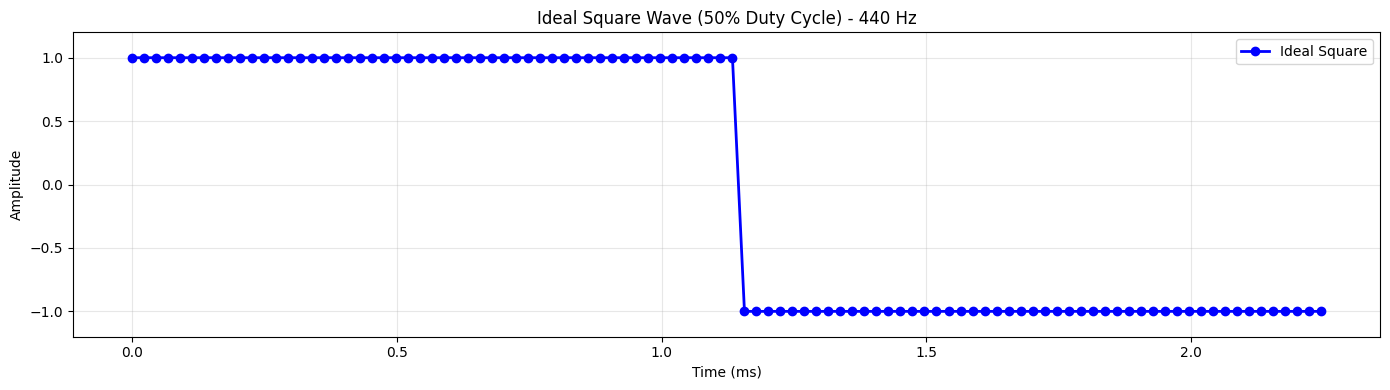

✓ Ideal square wave: instant transitions, classic square wave sound
  Min: -1.000, Max: 1.000
  Transitions: Instantaneous (may cause aliasing)


In [2]:
# Create ideal square wave oscillator
osc_ideal = SquareOscillator(frequency=440, mode="ideal", pulsewidth=0.5, gain_db=0)

# Generate one period
sample_rate = 44100
period_samples = int(sample_rate / 440)
samples_ideal = osc_ideal.get_samples(period_samples)

# Plot waveform
time = np.arange(period_samples) / sample_rate * 1000  # in milliseconds

plt.figure(figsize=(14, 4))
plt.plot(time, samples_ideal, "b-", marker="o", linewidth=2, label="Ideal Square")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Ideal Square Wave (50% Duty Cycle) - 440 Hz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)
plt.tight_layout()
plt.show()

print("✓ Ideal square wave: instant transitions, classic square wave sound")
print(f"  Min: {samples_ideal.min():.3f}, Max: {samples_ideal.max():.3f}")
print("  Transitions: Instantaneous (may cause aliasing)")

## 2. Bandlimited Square Wave

Uses MinBLEP (Minimum-phase Band-Limited Step) to eliminate aliasing.
This produces a professional-quality square wave suitable for high frequencies.

In [3]:
# Create bandlimited square wave oscillator
osc_bandlimited = SquareOscillator(
    frequency=440, mode="bandlimited", pulsewidth=0.5, gain_db=0
)

# Generate one period
samples_bandlimited = osc_bandlimited.get_samples(period_samples)

# Plot comparison with ideal
plt.figure(figsize=(14, 8))

# Full waveform comparison
plt.subplot(2, 1, 1)
plt.plot(time, samples_ideal, "b-", linewidth=2, alpha=0.7, label="Ideal")
plt.plot(time, samples_bandlimited, "r-", linewidth=2, alpha=0.7, label="Bandlimited")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Ideal vs Bandlimited Square Wave")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)

# Zoom in on transition
plt.subplot(2, 1, 2)
transition_start = period_samples // 2 - 20
transition_end = period_samples // 2 + 20
zoom_time = time[transition_start:transition_end]
plt.plot(
    zoom_time,
    samples_ideal[transition_start:transition_end],
    "b-",
    linewidth=2,
    marker="o",
    markersize=4,
    alpha=0.7,
    label="Ideal",
)
plt.plot(
    zoom_time,
    samples_bandlimited[transition_start:transition_end],
    "r-",
    linewidth=2,
    marker="s",
    markersize=4,
    alpha=0.7,
    label="Bandlimited",
)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Transition Detail (Zoomed In)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("✓ Bandlimited square wave: smooth transitions reduce aliasing")
print(f"  Min: {samples_bandlimited.min():.3f}, Max: {samples_bandlimited.max():.3f}")
print("  Transitions: Smoothed with MinBLEP kernel")

ValueError: Unknown square wave mode: bandlimited. Available modes: ['ideal', 'ideal_smooth', 'soft']

## 3. Soft Square Wave

Uses hyperbolic tangent (tanh) for smooth transitions. Creates a warmer,
more analog-style sound with reduced aliasing. The `smoothness` parameter
controls how sharp the transitions are (1.0 = very soft, 100.0 = nearly ideal).

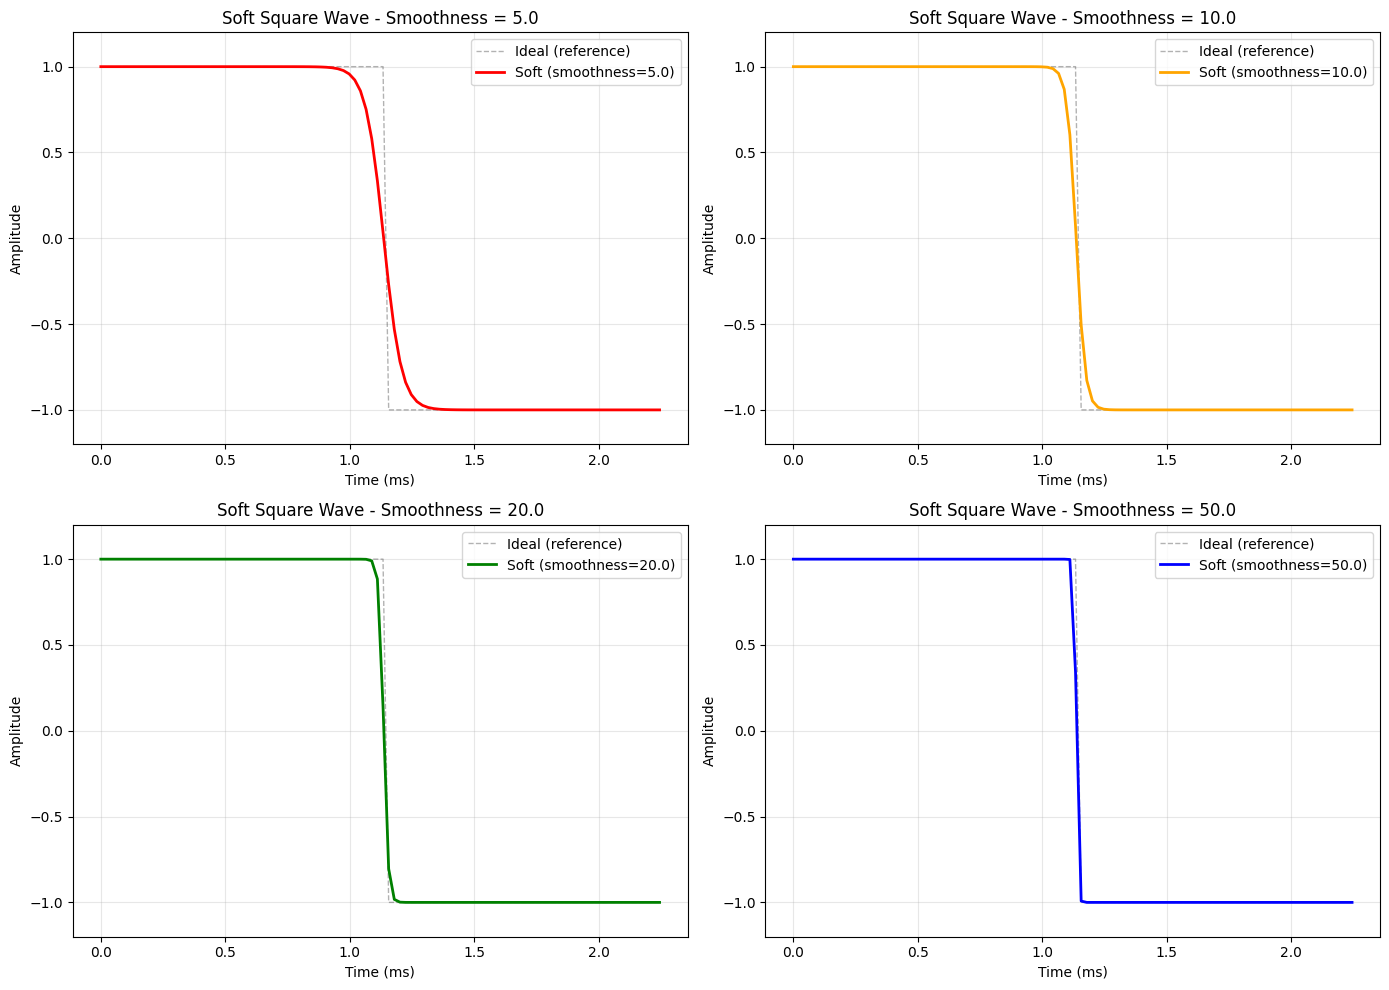

✓ Soft square waves: smooth transitions using tanh()
  Lower smoothness = softer, warmer sound
  Higher smoothness = sharper, closer to ideal


In [4]:
# Create soft square wave oscillators with different smoothness values
smoothness_values = [5.0, 10.0, 20.0, 50.0]
colors = ["red", "orange", "green", "blue"]

plt.figure(figsize=(14, 10))

# Plot each smoothness value
for idx, (smoothness, color) in enumerate(zip(smoothness_values, colors)):
    osc_soft = SquareOscillator(
        frequency=440, mode="soft", smoothness=smoothness, pulsewidth=0.5, gain_db=0
    )
    samples_soft = osc_soft.get_samples(period_samples)

    plt.subplot(2, 2, idx + 1)
    plt.plot(
        time, samples_ideal, "k--", linewidth=1, alpha=0.3, label="Ideal (reference)"
    )
    plt.plot(
        time,
        samples_soft,
        color=color,
        linewidth=2,
        label=f"Soft (smoothness={smoothness})",
    )
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Soft Square Wave - Smoothness = {smoothness}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("✓ Soft square waves: smooth transitions using tanh()")
print("  Lower smoothness = softer, warmer sound")
print("  Higher smoothness = sharper, closer to ideal")

## 4. Comparator Square Wave

Simulates a hardware comparator circuit with hysteresis. This creates an
analog-style square wave with characteristic behavior near the transitions.
The `hysteresis` parameter controls the stability (0.0 = no hysteresis, 0.1 = 10%).

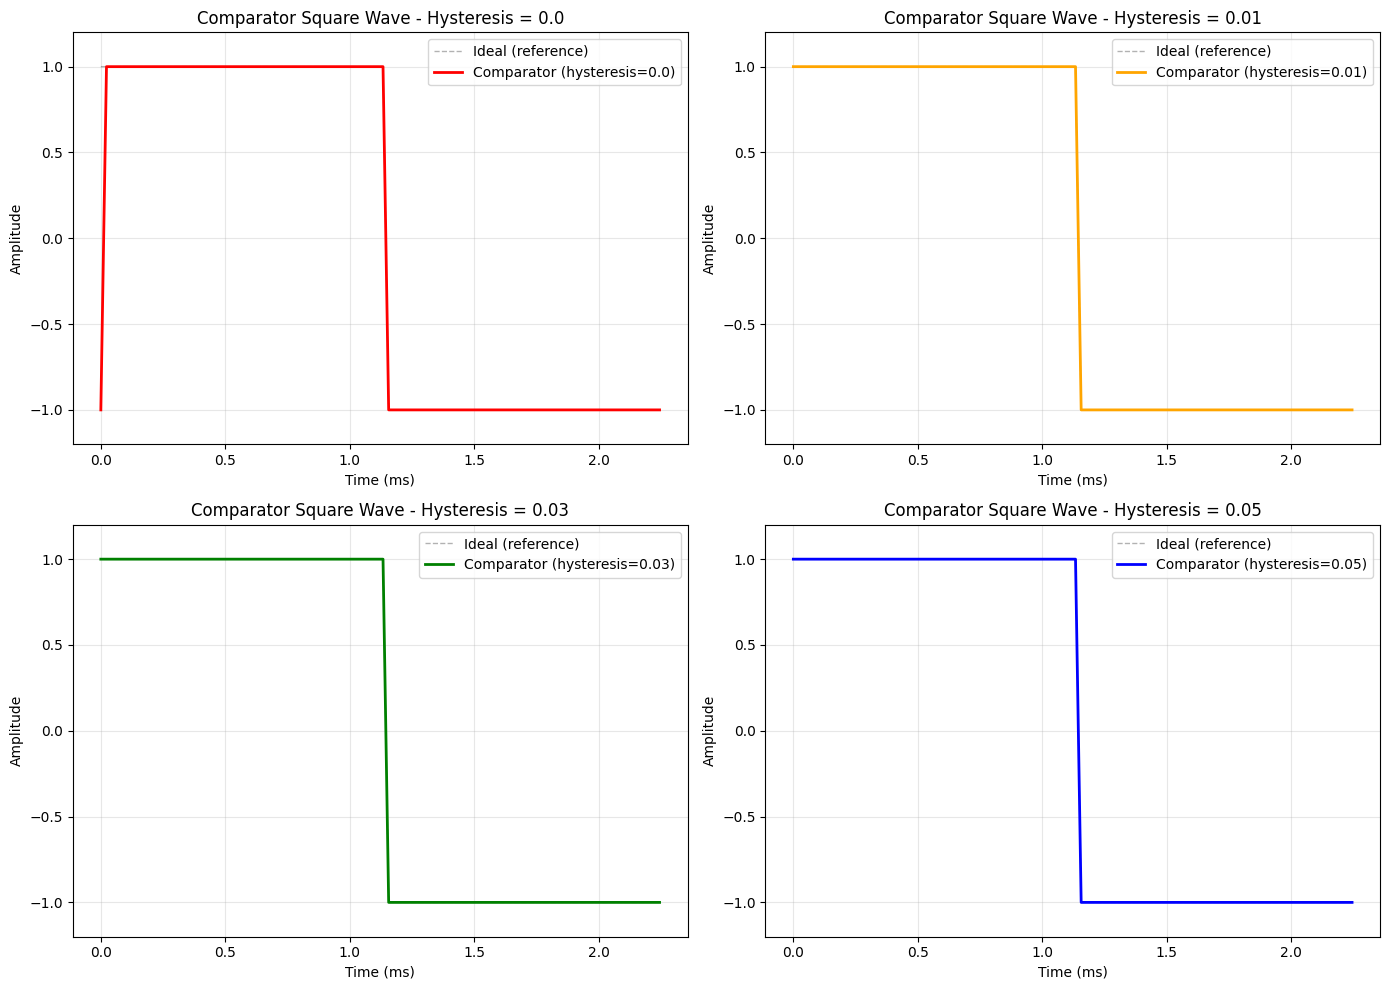

✓ Comparator square waves: analog circuit emulation
  Hysteresis creates stable transitions
  Higher hysteresis = more stable, smoother transitions


In [5]:
# Create comparator square wave oscillators with different hysteresis values
hysteresis_values = [0.0, 0.01, 0.03, 0.05]
colors = ["red", "orange", "green", "blue"]

plt.figure(figsize=(14, 10))

# Plot each hysteresis value
for idx, (hysteresis, color) in enumerate(zip(hysteresis_values, colors)):
    osc_comp = SquareOscillator(
        frequency=440,
        mode="comparator",
        hysteresis=hysteresis,
        pulsewidth=0.5,
        gain_db=0,
    )
    samples_comp = osc_comp.get_samples(period_samples)

    plt.subplot(2, 2, idx + 1)
    plt.plot(
        time, samples_ideal, "k--", linewidth=1, alpha=0.3, label="Ideal (reference)"
    )
    plt.plot(
        time,
        samples_comp,
        color=color,
        linewidth=2,
        label=f"Comparator (hysteresis={hysteresis})",
    )
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Comparator Square Wave - Hysteresis = {hysteresis}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("✓ Comparator square waves: analog circuit emulation")
print("  Hysteresis creates stable transitions")
print("  Higher hysteresis = more stable, smoother transitions")

## 5. Pulse Width Modulation (PWM)

All strategies support variable pulse width. Let's demonstrate different duty cycles.

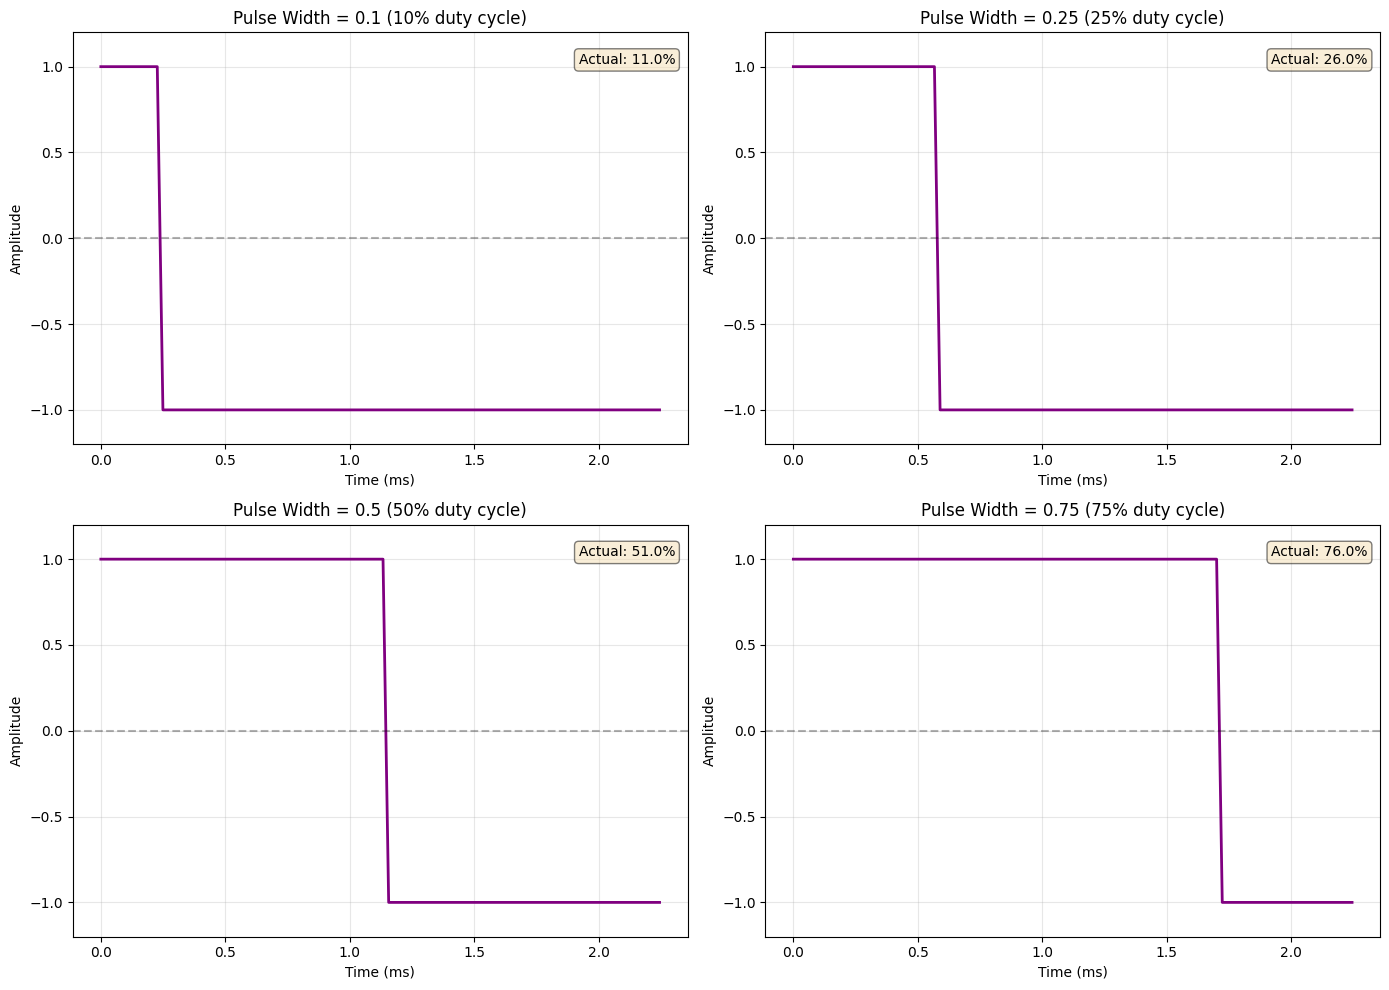

✓ Pulse width modulation: duty cycle from 0% to 100%
  0.5 = traditional square wave (50%)
  < 0.5 = narrow pulse
  > 0.5 = wide pulse


In [6]:
pulsewidths = [0.1, 0.25, 0.5, 0.75]
duty_cycle_labels = ["10%", "25%", "50%", "75%"]

plt.figure(figsize=(14, 10))

for idx, (pw, label) in enumerate(zip(pulsewidths, duty_cycle_labels)):
    # Use ideal for clarity
    osc_pwm = SquareOscillator(frequency=440, mode="ideal", pulsewidth=pw, gain_db=0)
    samples_pwm = osc_pwm.get_samples(period_samples)

    plt.subplot(2, 2, idx + 1)
    plt.plot(time, samples_pwm, "purple", linewidth=2)
    plt.axhline(y=0, color="k", linestyle="--", alpha=0.3)
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Pulse Width = {pw} ({label} duty cycle)")
    plt.grid(True, alpha=0.3)
    plt.ylim(-1.2, 1.2)

    # Add duty cycle indicator
    high_samples = np.sum(samples_pwm > 0)
    actual_duty = high_samples / len(samples_pwm) * 100
    plt.text(
        0.98,
        0.95,
        f"Actual: {actual_duty:.1f}%",
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.tight_layout()
plt.show()

print("✓ Pulse width modulation: duty cycle from 0% to 100%")
print("  0.5 = traditional square wave (50%)")
print("  < 0.5 = narrow pulse")
print("  > 0.5 = wide pulse")

## 6. Strategy Comparison at High Frequency

At higher frequencies, the differences between strategies become more apparent.
Aliasing is more noticeable with the ideal square wave.

[BLEP] Starting table generation...
[BLEP] n=1024
[BLEP] t created, len=1024
[BLEP] sinc created
[BLEP] window created
[BLEP] cumsum done
[BLEP] normalized
[BLEP] clamped
[BLEP] Table generation complete, len=1024


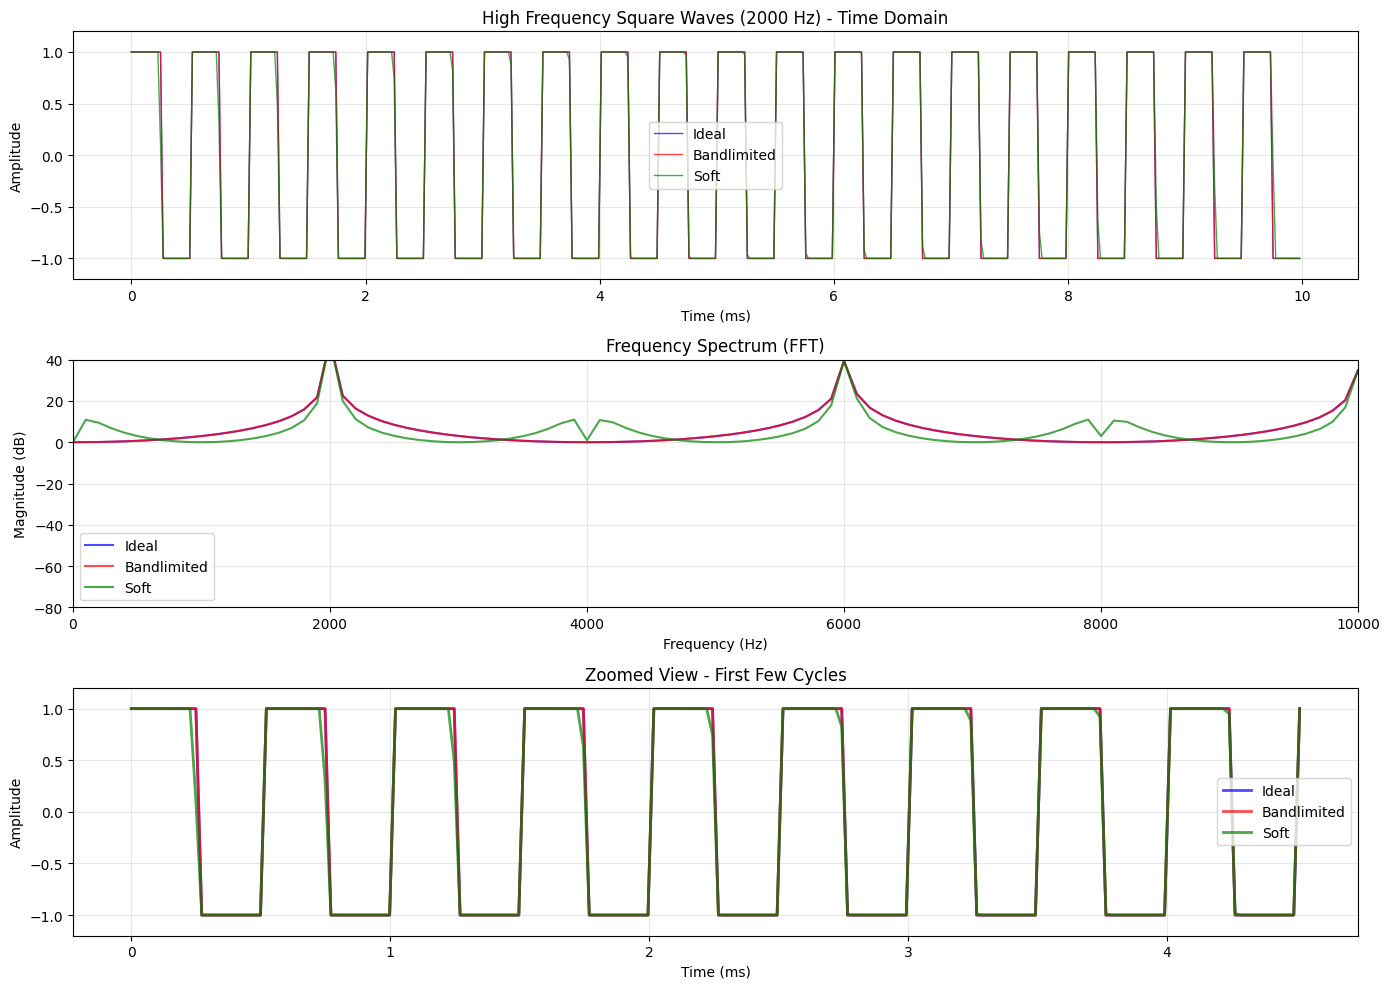

✓ High frequency comparison (2000 Hz):
  Ideal: Sharp harmonics, potential aliasing
  Bandlimited: Clean spectrum, no aliasing
  Soft: Reduced high-frequency content, warm sound


In [7]:
# Generate high frequency square waves (2 kHz)
high_freq = 2000
osc_ideal_hf = SquareOscillator(frequency=high_freq, mode="ideal", gain_db=0)
osc_bandlimited_hf = SquareOscillator(
    frequency=high_freq, mode="bandlimited", gain_db=0
)
osc_soft_hf = SquareOscillator(
    frequency=high_freq, mode="soft", smoothness=15.0, gain_db=0
)

# Generate samples
n_samples = int(sample_rate * 0.01)  # 10ms
samples_ideal_hf = osc_ideal_hf.get_samples(n_samples)
samples_bandlimited_hf = osc_bandlimited_hf.get_samples(n_samples)
samples_soft_hf = osc_soft_hf.get_samples(n_samples)

time_hf = np.arange(n_samples) / sample_rate * 1000

plt.figure(figsize=(14, 10))

# Time domain comparison
plt.subplot(3, 1, 1)
plt.plot(time_hf, samples_ideal_hf, "b-", linewidth=1, alpha=0.7, label="Ideal")
plt.plot(
    time_hf, samples_bandlimited_hf, "r-", linewidth=1, alpha=0.7, label="Bandlimited"
)
plt.plot(time_hf, samples_soft_hf, "g-", linewidth=1, alpha=0.7, label="Soft")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title(f"High Frequency Square Waves ({high_freq} Hz) - Time Domain")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)

# Frequency spectrum (FFT) comparison
plt.subplot(3, 1, 2)
fft_ideal = np.fft.rfft(samples_ideal_hf)
fft_bandlimited = np.fft.rfft(samples_bandlimited_hf)
fft_soft = np.fft.rfft(samples_soft_hf)
freqs = np.fft.rfftfreq(n_samples, 1 / sample_rate)

plt.plot(
    freqs, 20 * np.log10(np.abs(fft_ideal) + 1e-10), "b-", alpha=0.7, label="Ideal"
)
plt.plot(
    freqs,
    20 * np.log10(np.abs(fft_bandlimited) + 1e-10),
    "r-",
    alpha=0.7,
    label="Bandlimited",
)
plt.plot(freqs, 20 * np.log10(np.abs(fft_soft) + 1e-10), "g-", alpha=0.7, label="Soft")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Spectrum (FFT)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 10000)
plt.ylim(-80, 40)

# Zoom on a few cycles
plt.subplot(3, 1, 3)
zoom_samples = 200
plt.plot(
    time_hf[:zoom_samples],
    samples_ideal_hf[:zoom_samples],
    "b-",
    linewidth=2,
    alpha=0.7,
    label="Ideal",
)
plt.plot(
    time_hf[:zoom_samples],
    samples_bandlimited_hf[:zoom_samples],
    "r-",
    linewidth=2,
    alpha=0.7,
    label="Bandlimited",
)
plt.plot(
    time_hf[:zoom_samples],
    samples_soft_hf[:zoom_samples],
    "g-",
    linewidth=2,
    alpha=0.7,
    label="Soft",
)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Zoomed View - First Few Cycles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print(f"✓ High frequency comparison ({high_freq} Hz):")
print("  Ideal: Sharp harmonics, potential aliasing")
print("  Bandlimited: Clean spectrum, no aliasing")
print("  Soft: Reduced high-frequency content, warm sound")

## 7. Runtime Mode Switching

You can change the square wave generation algorithm without recreating the oscillator.

[BLEP] Starting table generation...
[BLEP] n=1024
[BLEP] t created, len=1024
[BLEP] sinc created
[BLEP] window created
[BLEP] cumsum done
[BLEP] normalized
[BLEP] clamped
[BLEP] Table generation complete, len=1024


✓ Runtime mode switching demonstration:

  Mode: ideal        - Min: -1.000, Max:  1.000
  Mode: bandlimited  - Min: -1.000, Max:  1.000
  Mode: soft         - Min: -1.000, Max:  1.000
  Mode: comparator   - Min: -1.000, Max:  1.000


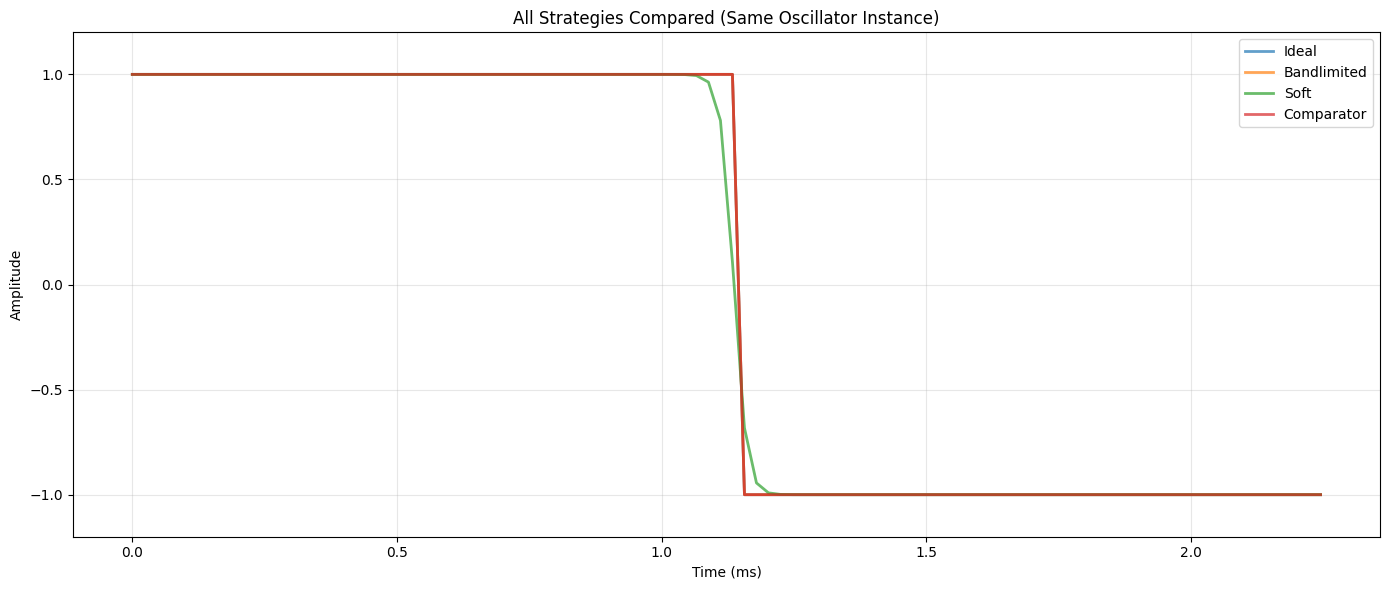


✓ Mode switching successful - no oscillator recreation needed!


In [8]:
# Create oscillator with one mode
osc_switchable = SquareOscillator(
    frequency=440, mode="ideal", pulsewidth=0.5, gain_db=0
)

print("✓ Runtime mode switching demonstration:\n")

# Generate samples with different modes
modes = ["ideal", "bandlimited", "soft", "comparator"]
mode_samples = {}

for mode in modes:
    if mode == "ideal":
        osc_switchable.set_mode("ideal")
    elif mode == "bandlimited":
        osc_switchable.set_mode("bandlimited")
    elif mode == "soft":
        osc_switchable.set_mode("soft", smoothness=15.0)
    elif mode == "comparator":
        osc_switchable.set_mode("comparator", hysteresis=0.02)

    # Reset phase for consistent comparison
    osc_switchable._i = 0
    mode_samples[mode] = osc_switchable.get_samples(period_samples)
    print(
        f"  Mode: {mode:12s} - Min: {mode_samples[mode].min():6.3f}, Max: {mode_samples[mode].max():6.3f}"
    )

# Plot all modes
plt.figure(figsize=(14, 6))
for mode, color in zip(modes, ["blue", "red", "green", "purple"]):
    plt.plot(time, mode_samples[mode], linewidth=2, alpha=0.7, label=mode.capitalize())

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("All Strategies Compared (Same Oscillator Instance)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)
plt.tight_layout()
plt.show()

print("\n✓ Mode switching successful - no oscillator recreation needed!")

## 8. Available Modes

Query the oscillator for available square wave generation modes.

In [9]:
available_modes = SquareOscillator.get_available_modes()

print("Available square wave generation modes:")
print("=" * 60)
for mode in available_modes:
    print(f"  • {mode}")

print("\nMode details:")
print("-" * 60)
print("ideal       : Traditional square wave (instant transitions)")
print("bandlimited : MinBLEP antialiased square wave")
print("soft        : Smooth transitions using tanh()")
print("comparator  : Sine comparator with hysteresis")

Available square wave generation modes:
  • ideal
  • bandlimited
  • soft
  • comparator

Mode details:
------------------------------------------------------------
ideal       : Traditional square wave (instant transitions)
bandlimited : MinBLEP antialiased square wave
soft        : Smooth transitions using tanh()
comparator  : Sine comparator with hysteresis


## 9. Strategy Characteristics Summary


In [10]:
# Create a summary table
import pandas as pd

summary_data = {
    "Strategy": ["Ideal", "Bandlimited", "Soft", "Comparator"],
    "CPU Cost": ["★☆☆☆☆", "★★★★☆", "★★☆☆☆", "★★☆☆☆"],
    "Quality": ["★★★☆☆", "★★★★★", "★★★★☆", "★★★☆☆"],
    "Aliasing": ["High", "None", "Low", "Medium"],
    "Sound Character": [
        "Sharp, digital",
        "Clean, professional",
        "Warm, analog",
        "Analog circuit",
    ],
    "Best For": [
        "Retro, low freq",
        "High-quality synthesis",
        "Analog-style",
        "Circuit modeling",
    ],
    "Parameters": [
        "None",
        "sample_rate (auto)",
        "smoothness (1-100)",
        "hysteresis (0-0.1)",
    ],
}

df = pd.DataFrame(summary_data)
print("\nSquare Wave Strategy Comparison")
print("=" * 100)
print(df.to_string(index=False))


Square Wave Strategy Comparison
   Strategy CPU Cost Quality Aliasing     Sound Character               Best For         Parameters
      Ideal    ★☆☆☆☆   ★★★☆☆     High      Sharp, digital        Retro, low freq               None
Bandlimited    ★★★★☆   ★★★★★     None Clean, professional High-quality synthesis sample_rate (auto)
       Soft    ★★☆☆☆   ★★★★☆      Low        Warm, analog           Analog-style smoothness (1-100)
 Comparator    ★★☆☆☆   ★★★☆☆   Medium      Analog circuit       Circuit modeling hysteresis (0-0.1)


## Conclusion

AudioPlayground provides four different square wave generation strategies:

1. **Ideal** - Fast, classic square wave with aliasing (default)
2. **Bandlimited** - Professional quality, antialiased using MinBLEP
3. **Soft** - Warm, analog-style with smooth transitions
4. **Comparator** - Analog circuit emulation with hysteresis

Each strategy is optimized for different use cases and can be switched at runtime.
Use `mode` parameter in constructor or `set_mode()` method to switch strategies.

**Try it yourself:**
```python
osc = SquareOscillator(frequency=440, mode="bandlimited")
osc.set_mode("soft", smoothness=15.0)
samples = osc.get_samples(44100)
```
